In [30]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math
from tqdm import tqdm

optuna.logging.set_verbosity(optuna.logging.ERROR)

In [3]:
def load_candles(base,quote,timeframe):
    data = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/{base}_{quote}-{timeframe}.json')
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

In [4]:

# # Load the data
# data = load_candles('ETH','USDT','8h')
# data = data['2021-11-01':].copy()


best_params= {'tenkan_period': 38, 'kijun_period': 78, 'senkou_span_b_period': 53}


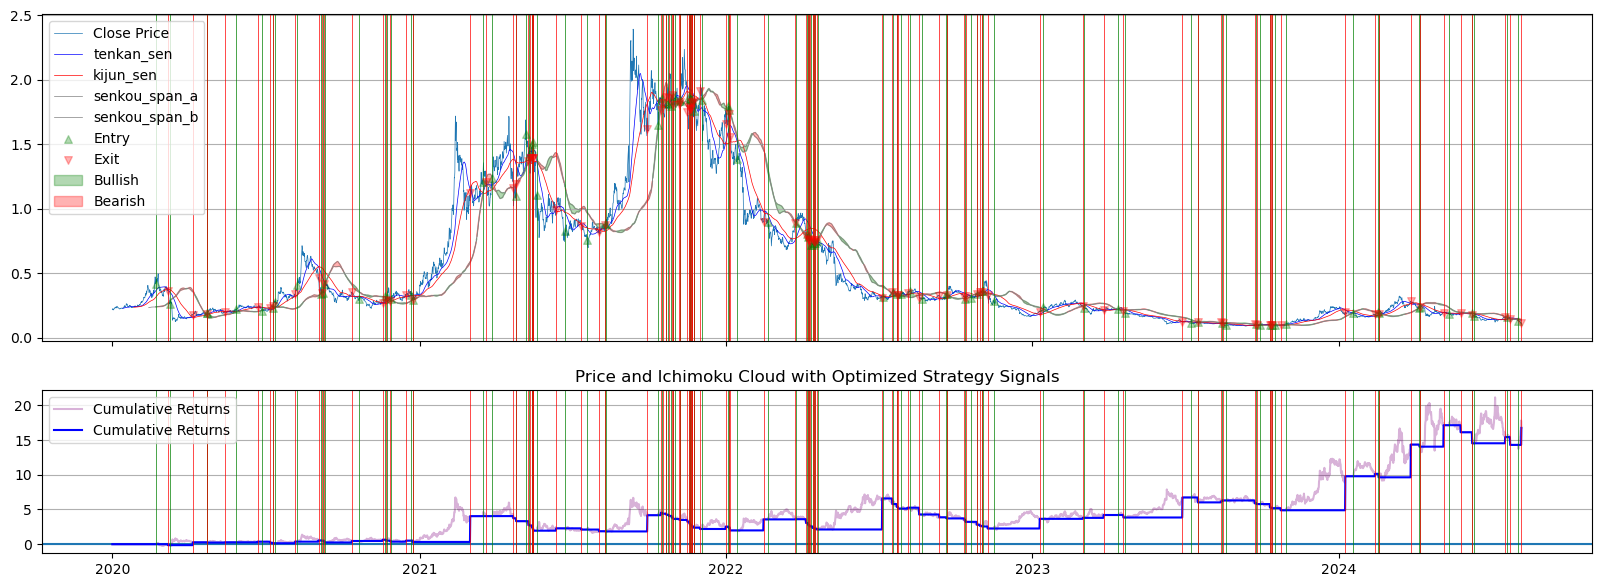

Final Cumulative Return with Optimized Parameters: 16.69
Sharpe Ratio: 1.12
Total Return: 16.69
Annualized Return: 1.12
Number of Trades: 198
Best params: {'tenkan_period': 38, 'kijun_period': 78, 'senkou_span_b_period': 53}


In [67]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
def indicators(data, params):    
    data['lclose'] = data['close'].apply(np.log)
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)

    data['bull'] = (data['tenkan_sen'] > data['kijun_sen']) & \
                   (data['close'] > data['senkou_span_a']) & \
                   (data['close'] > data['senkou_span_b'])
                  
    data['bull_exit'] = (data['close'] < data['senkou_span_a']) | \
                        (data['close'] < data['senkou_span_b'])
                        
    
    data['bear'] = (data['tenkan_sen'] < data['kijun_sen']) & \
                   (data['close'] < data['senkou_span_a']) & \
                   (data['close'] < data['senkou_span_b'])
                  
    data['bear_exit'] = (data['close'] > data['senkou_span_a']) | \
                        (data['close'] > data['senkou_span_b'])
                        
    return data
    
def backtest(data, short_long=None, pos_mult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    # if 1 in short_long:
    #     data.loc[data['bull'], 'position'] = 1        
    #     data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    # if -1 in short_long:
    #     data.loc[(data['bear']), 'position'] = -1    
    #     data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    data['position'] = pos_mult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) - 1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) - 1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / 8)
    sharpe_ratio = annualized_return / annualized_volatility
    

    # Calculate trade returns
    # data['trade_returns'] = data['strategy_returns'] * data['trade'].shift(-1)

    # Calculate winning trades and losing trades
    # winning_trades = data['trade_returns'][data['trade_returns'] > 0]
    # losing_trades = data['trade_returns'][data['trade_returns'] <= 0]

    # Calculate win ratio
    # if number_of_trades > 0:
    #     win_ratio = len(winning_trades) / number_of_trades
    # else:
    #     win_ratio = np.nan

    # Calculate average win and average loss
    # average_win = winning_trades.mean() if len(winning_trades) > 0 else np.nan
    # average_loss = losing_trades.mean() if len(losing_trades) > 0 else np.nan

    
    return {'sharpe_ratio': sharpe_ratio, 'total_return': total_return, 'annualized_return':annualized_return,
            'number_of_trades':number_of_trades,
            # 'win_ratio':win_ratio,'average_win':average_win,'average_loss':average_loss
            }

def decorate_trades(data):
    positions_shifted = data['position'].shift().fillna(0).astype(int)
    data['entry_point'] = ((data['position'] != 0) & (data['position'] == np.sign(data['trade']))).astype(int)
    data['exit_point'] = ((positions_shifted != 0) & (positions_shifted == np.sign(-data['trade']))).astype(int)

    data['cum_trade_returns'] = data['cumulative_returns'] * data['exit_point']
    # data.loc[(data['trade'] == 0), 'cum_trade_returns'] = 0
    data['cum_trade_returns'].replace(0, pd.NA, inplace=True)
    data['cum_trade_returns'] = data['cum_trade_returns'].fillna(method='ffill').fillna(0)#.diff().fillna(0)
    data['pct_cum_trade_returns'] = np.exp(data['cum_trade_returns']) -1
    return data
 

def optimize(data, short_long=None):
    # Define the objective function for Optuna
    def objective(trial):
        global data
        params = {
            'tenkan_period': trial.suggest_int('tenkan_period', 7, 50),
            'kijun_period': trial.suggest_int('kijun_period', 20, 100),
            'senkou_span_b_period': trial.suggest_int('senkou_span_b_period', 7, 100)
        }
        
        data = indicators(data,params)
        # sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(data)
        results = backtest(data,short_long)
        
        return results['sharpe_ratio'] #/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)

    # Get the best parameters
    return study
    

def print_performance(data, best_params, window=None, short_long=None):
    # Set default window to the entire DataFrame if not provided
    if window is None:
        window = data.index
    
    indicators(data, best_params)
    results = backtest(data,short_long=short_long)
    decorate_trades(data)
    
    entry_points = data.index[(data['entry_point'] == 1)]
    exit_points = data.index[(data['exit_point'] == 1)]
    entry_prices = data.loc[entry_points, 'close'].values
    exit_prices = data.loc[exit_points, 'close'].values

    # Ensure entry and exit points are aligned
    # if len(exit_points) < len(entry_points):
    #     entry_points = entry_points[:-1]

    # Calculate trade PnL
    entry_prices = data.loc[entry_points, 'close'].values
    exit_prices = data.loc[exit_points, 'close'].values
    trade_pnl = (exit_prices - entry_prices) / entry_prices  # Calculate percentage return

    # Plot the results with the best parameters
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7), sharex=True, height_ratios=[2, 1])

    ax1.plot(data.index, data['close'], label='Close Price', lw=0.5)
    ax1.plot(data.index, data['tenkan_sen'], label='tenkan_sen', color='blue', lw=0.5)
    ax1.plot(data.index, data['kijun_sen'], label='kijun_sen', color='red', lw=0.5)
    ax1.plot(data.index, data['senkou_span_a'], label='senkou_span_a', color='gray', lw=0.5)
    ax1.plot(data.index, data['senkou_span_b'], label='senkou_span_b', color='gray', lw=0.5)
    ax1.scatter(entry_points, data.loc[entry_points, 'close'], marker='^', color='g', s=30, label='Entry', zorder=5, alpha=0.3)
    ax1.scatter(exit_points, data.loc[exit_points, 'close'], marker='v', color='r', s=30, label='Exit', zorder=5, alpha=0.3)
    ax1.fill_between(data.index, data['senkou_span_a'], data['senkou_span_b'], where=(data['senkou_span_a'] > data['senkou_span_b']), color='green', alpha=0.3, label='Bullish')
    ax1.fill_between(data.index, data['senkou_span_a'], data['senkou_span_b'], where=(data['senkou_span_a'] < data['senkou_span_b']), color='red', alpha=0.3, label='Bearish')
    ax1.legend(loc='best')
    plt.title('Price and Ichimoku Cloud with Optimized Strategy Signals')

    ax2.axhline(0)
    ax2.plot(data['pct_cumulative_returns'], label='Cumulative Returns', color='purple', alpha=0.3)
    ax2.plot(data['pct_cum_trade_returns'], label='Cumulative Returns', color='blue')
    
    ax2.legend(loc='best')
    
    for x in entry_points: ax1.axvline(x, lw=0.5, c='green');ax2.axvline(x, lw=0.5, c='green')
    for x in exit_points: ax1.axvline(x, lw=0.5, c='red');ax2.axvline(x, lw=0.5, c='red')
    ax1.grid(axis='y')
    ax2.grid(axis='y')
    
    plt.show()
    # Print final cumulative return with the best parameters
    print(f"Final Cumulative Return with Optimized Parameters: {data['pct_cumulative_returns'].iloc[-1]:.2f}")

    # Print performance metrics
    print(f"Sharpe Ratio: {results['sharpe_ratio']:.2f}")
    print(f"Total Return: {results['total_return']:.2f}")
    print(f"Annualized Return: {results['annualized_return']:.2f}")
    print(f"Number of Trades: {results['number_of_trades']:.0f}")
    # print(f"Win Ratio: {results['win_ratio']:.2f}")
    # print(f"Average Win: {results['average_win']:.4f}")
    # print(f"Average Loss: {results['average_loss']:.4f}")
    

# Load the data
data = load_candles('ALGO','USDT','8h')
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [44]:
data[data.trade != 0].head(5)

,open,high,low,close,volume,lclose,tenkan_sen,kijun_sen,senkou_span_a,senkou_span_b,...,position,trade,strategy_returns,cumulative_returns,pct_strategy_returns,pct_cumulative_returns,entry_point,exit_point,cum_trade_returns,pct_cum_trade_returns
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.2164,0.2202,0.2152,0.2158,792393.81,-1.533403,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,0,0,0.000000,0.000000
2020-02-07 00:00:00,0.2883,0.2933,0.2807,0.2931,3165268.62,-1.227241,0.252240,0.249502,0.233911,0.235326,...,1,1.0,-0.002000,-0.002000,-0.001998,-0.001998,1,0,0.000000,0.000000
2020-03-07 08:00:00,0.3660,0.3673,0.3585,0.3630,2743135.73,-1.013352,0.382940,0.385155,0.319114,0.341200,...,0,-1.0,-0.011050,0.209889,-0.010989,0.233541,0,1,0.209889,0.233541
2020-03-08 08:00:00,0.3331,0.3343,0.3051,0.3090,6198747.24,-1.174414,0.374838,0.384841,0.323475,0.344306,...,-1,-1.0,-0.002000,0.207889,-0.001998,0.231076,1,0,0.209889,0.233541
2020-03-30 16:00:00,0.1547,0.1566,0.1535,0.1547,4599156.37,-1.866268,0.152700,0.151055,0.346962,0.331794,...,0,1.0,-0.003294,0.897743,-0.003288,1.454057,0,1,0.897743,1.454057


In [51]:
(pd.Series([(0.3630 / 0.2931 - 1) , -(0.1547 / 0.3090 - 1)]) +1 ).cumprod() - 1

0    0.238485
1    0.856926
dtype: float64

best_params= {'tenkan_period': 8, 'kijun_period': 37, 'senkou_span_b_period': 43}


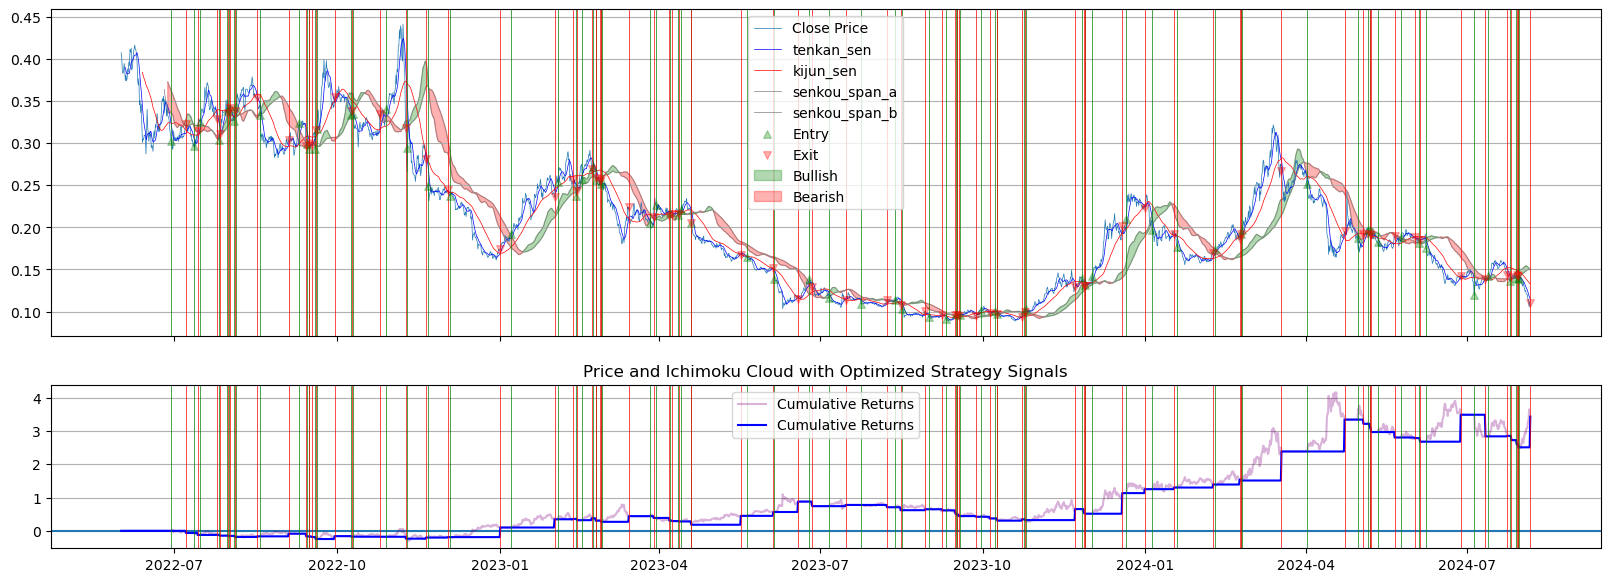

Final Cumulative Return with Optimized Parameters: 3.43
Sharpe Ratio: 1.31
Total Return: 3.43
Annualized Return: 0.93
Number of Trades: 148
Best params: {'tenkan_period': 8, 'kijun_period': 37, 'senkou_span_b_period': 43}


In [64]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [55]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


Processing: 100%|██████████| 95/95 [03:25<00:00,  2.16s/it]


In [56]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

100%|██████████| 95/95 [00:01<00:00, 67.96it/s]


In [57]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

,period,days,tenkan_period,kijun_period,senkou_span_b_period,sharpe_ratio,total_return,annualized_return,number_of_trades
18,23,1,31,97,19,1.924387,18.772848,3.214487,38.0
1,6,0,50,100,100,0.947580,15.532118,0.868055,232.0
9,14,1,45,100,100,1.440647,14.346303,1.848672,72.0
12,17,1,50,94,72,1.546178,12.407976,2.136544,62.0
10,15,1,45,100,97,1.423098,11.715932,1.915407,72.0
3,8,0,39,93,66,0.998844,9.284923,1.000634,168.0
14,19,1,30,93,20,1.537350,9.166108,2.247474,72.0
0,5,0,32,95,23,0.773690,8.514357,0.649159,304.0
11,16,1,46,97,96,1.391054,8.466674,1.881732,66.0
16,21,1,46,97,98,1.563435,8.012556,2.410418,56.0


best_params= {'tenkan_period': 12, 'kijun_period': 81, 'senkou_span_b_period': 31}


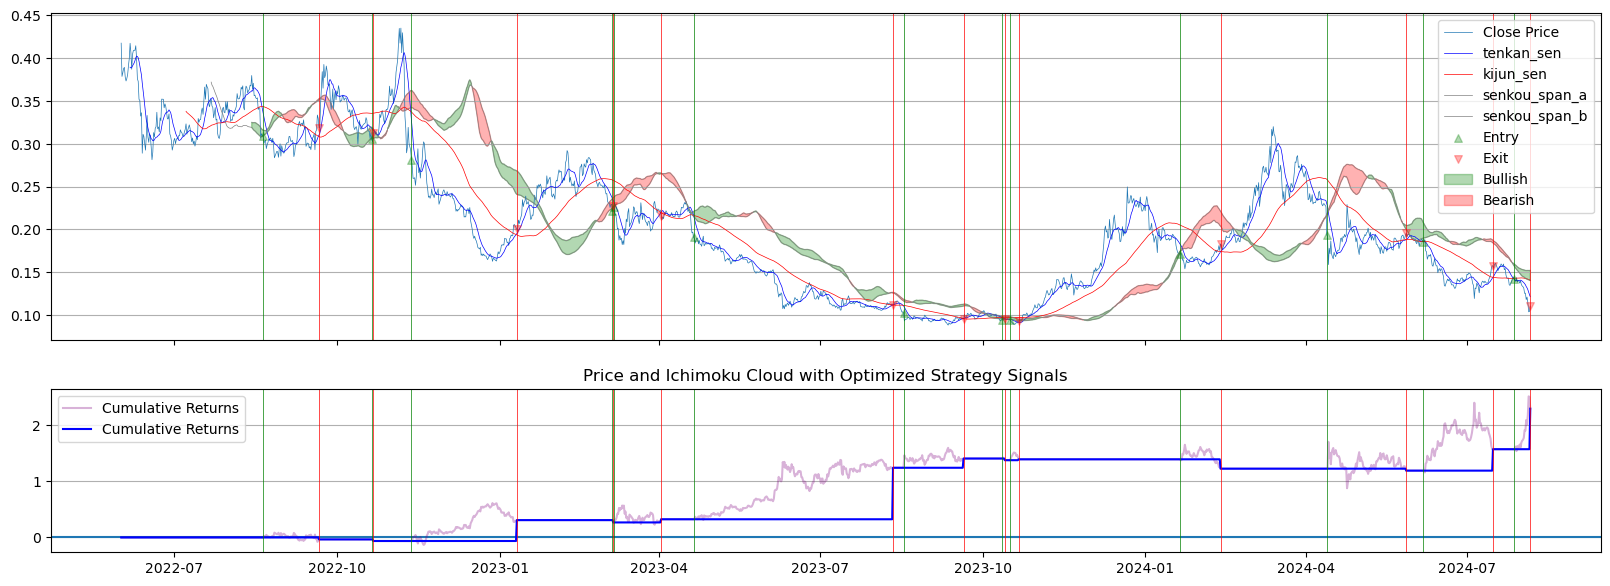

Final Cumulative Return with Optimized Parameters: 2.29
Sharpe Ratio: 1.47
Total Return: 2.29
Annualized Return: 0.96
Number of Trades: 26
Best params: {'tenkan_period': 12, 'kijun_period': 81, 'senkou_span_b_period': 31}


In [69]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
